
**File:** `cleaned_users.csv`

This notebook looks at prospective plot buyers/leads — their demographics, budget, and
behavior — to understand what's related to whether someone actually purchased a plot.


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (9, 5)
pd.set_option('display.max_columns', 60)


In [2]:
users = pd.read_csv('../data/processed/real_estate_user_cleaned.csv')
print("Shape:", users.shape)
users.head()

Shape: (12000, 27)


,Customer_ID,Age,Gender,Occupation,City,Monthly_Income,Annual_Income,Family_Size,Current_Housing_Status,Plot_Budget,Preferred_Plot_Size_SqFt,Preferred_Location,Distance_to_City_Center_km,Purpose,Loan_Required,Expected_Purchase_Timeline,Lead_Source,Enquiry_Date,Previous_Enquiry,Site_Visit,Negotiation_Done,Booking_Done,Purchase_Probability,Purchase_Intent,Purchased,Purchase_Value,Outlier_Flag
0,CUST_20988,21,Male,IT & Software,Mumbai,131500.0,1578000.0,2,Owned Flat/House,7.020000e+06,1500.0,Suburbs,33.800000,Self-use,0,1-3 years,Google & Social Media Ads,2024-07-19,0,0,0,0,0.0639,Low,0,0.0,Inlier
1,CUST_16662,29,Male,Real Estate & Construction,Kolkata,43800.0,525600.0,4,Owned Flat/House,2.000000e+06,600.0,Within City Limits,17.000000,Self-use,1,1-3 years,Magicbricks / Real Estate Portal,2025-01-13,1,1,0,0,0.0668,Low,0,0.0,Inlier
2,CUST_10543,50,Male,Retail & Commerce,Noida,179000.0,2148000.0,2,Owned Flat/House,5.710000e+06,1200.0,Suburbs,20.300000,Investment,1,0-6 months,Channel Partner / Broker,2024-10-25,0,1,1,1,0.9900,High,1,5550000.0,Inlier
3,CUST_15741,44,Male,Retail & Commerce,Pune,45700.0,548400.0,4,Living with Parents,2.300000e+06,1000.0,Periphery / Growth Corridor,40.900000,Self-use,1,6-12 months,Print / Newspaper Ad,2025-06-06,1,1,0,0,0.2293,Low,0,0.0,Inlier
4,CUST_16911,38,Male,Self-Employed / Business,Ahmedabad,219400.0,2632800.0,4,Rented,1.635451e+07,1500.0,Suburbs,23.534197,Self-use,1,0-6 months,Magicbricks / Real Estate Portal,2024-09-30,0,1,0,1,0.7678,High,1,8930000.0,Inlier


## 1. Purchased — class balance (pie chart)

Purchased
0    7110
1    4890
Name: count, dtype: int64


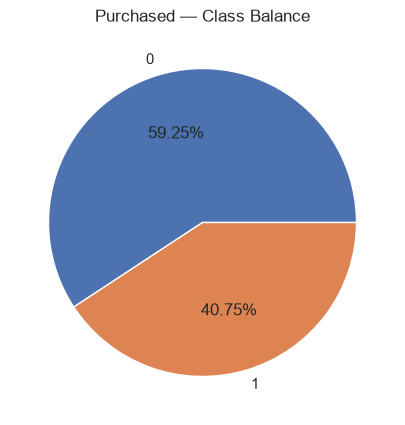

In [4]:
purchase_counts = users['Purchased'].value_counts()
print(purchase_counts)

plt.figure(figsize=(5, 5))
plt.pie(purchase_counts, labels=purchase_counts.index, autopct='%1.2f%%')
plt.title('Purchased — Class Balance')
plt.savefig('../reports/figures/class_balance.png', dpi=300, bbox_inches='tight')
plt.show()


## 2. Demographics: Age, Gender, Family size

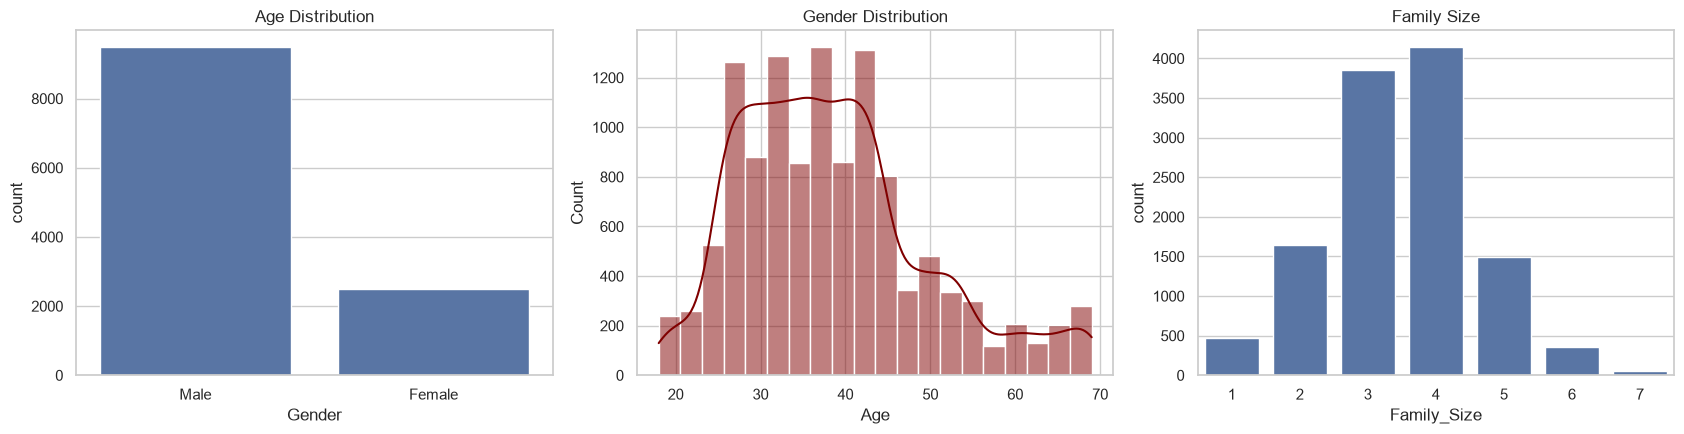

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(17, 4.5))

sns.countplot(data=users, x='Gender', ax=axes[0])
axes[1].set_title('Gender Distribution')

sns.histplot(users['Age'], bins=20, kde=True,color="maroon", ax=axes[1])
axes[0].set_title('Age Distribution')

sns.countplot(data=users, x='Family_Size', ax=axes[2])
axes[2].set_title('Family Size')
plt.savefig('../reports/figures/demographic_AGF.png', dpi=300, bbox_inches='tight')

plt.tight_layout()
plt.show()

## 3. Income: Monthly vs Annual

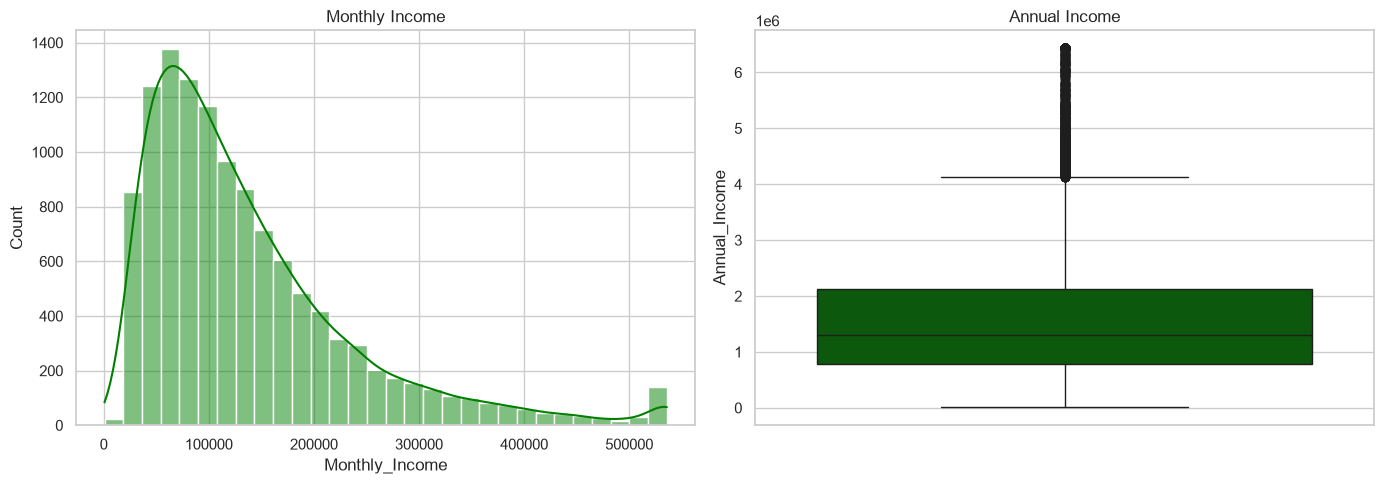

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(users['Monthly_Income'], bins=30, kde=True, ax=axes[0], color='green')
axes[0].set_title('Monthly Income')

sns.boxplot(y=users['Annual_Income'], ax=axes[1], color='darkgreen')
axes[1].set_title('Annual Income')

plt.savefig('../reports/figures/Income(Monthly vs Annual).png', dpi=300, bbox_inches='tight')
plt.tight_layout()
plt.show()


## 4. City-wise lead count

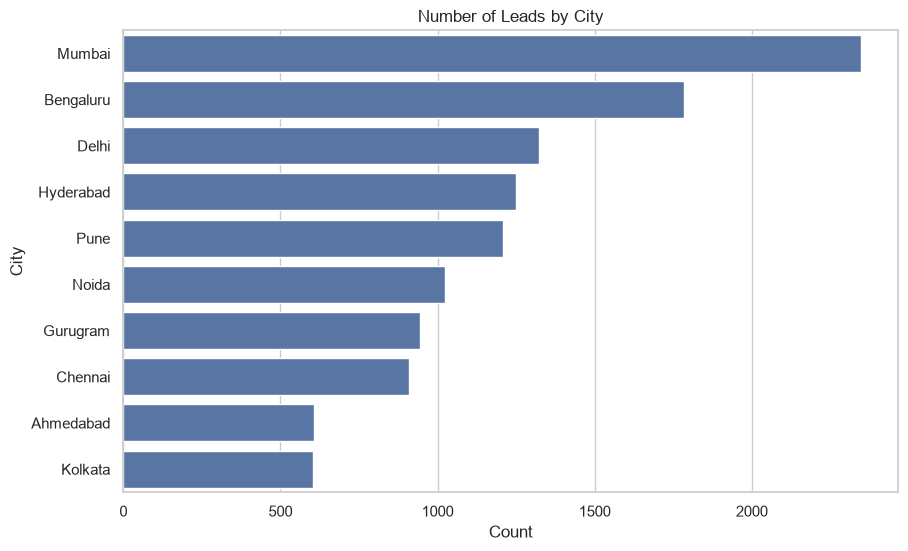

In [7]:
city_counts = users['City'].value_counts()
"""print(city_counts)"""

plt.figure(figsize=(10, 6))
sns.barplot(x=city_counts.values, y=city_counts.index)
plt.title('Number of Leads by City')
plt.xlabel('Count')
plt.savefig('../reports/figures/citywise_leadcount.png', dpi=300, bbox_inches='tight')
plt.show()


## 5. Plot budget & preferred plot size

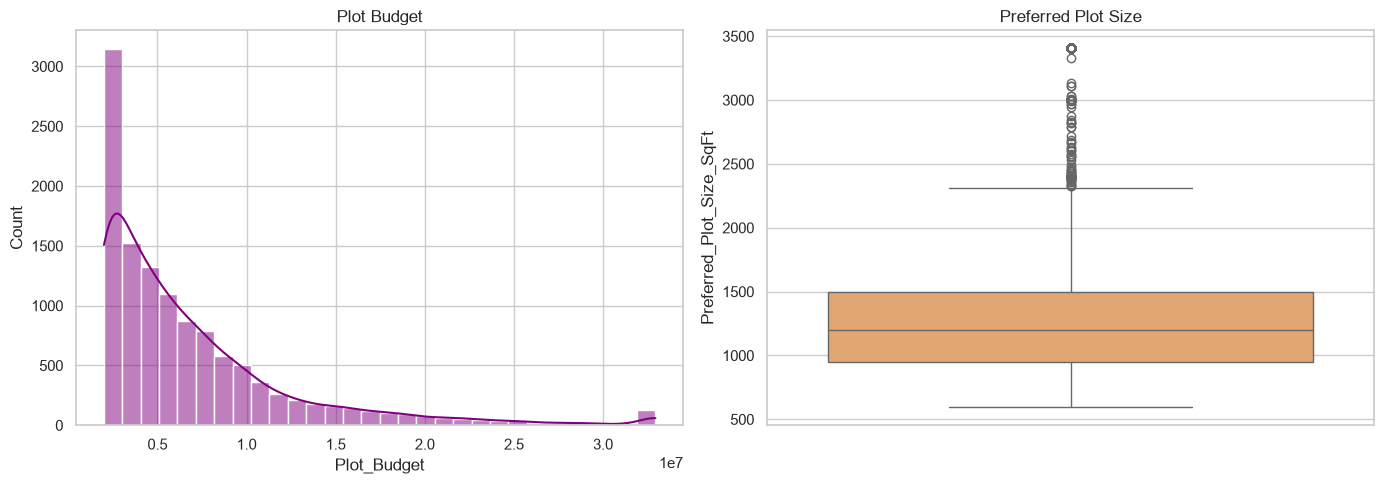

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(users['Plot_Budget'], bins=30, kde=True, ax=axes[0], color='purple')
axes[0].set_title('Plot Budget')

sns.boxplot(y=users['Preferred_Plot_Size_SqFt'], ax=axes[1], color='sandybrown')
axes[1].set_title('Preferred Plot Size')

plt.savefig('../reports/figures/plot_budget_&_plot_size.png', dpi=300, bbox_inches='tight')
plt.tight_layout()
plt.show()


## 6. Loan requirement , Purpose & Purchase intent

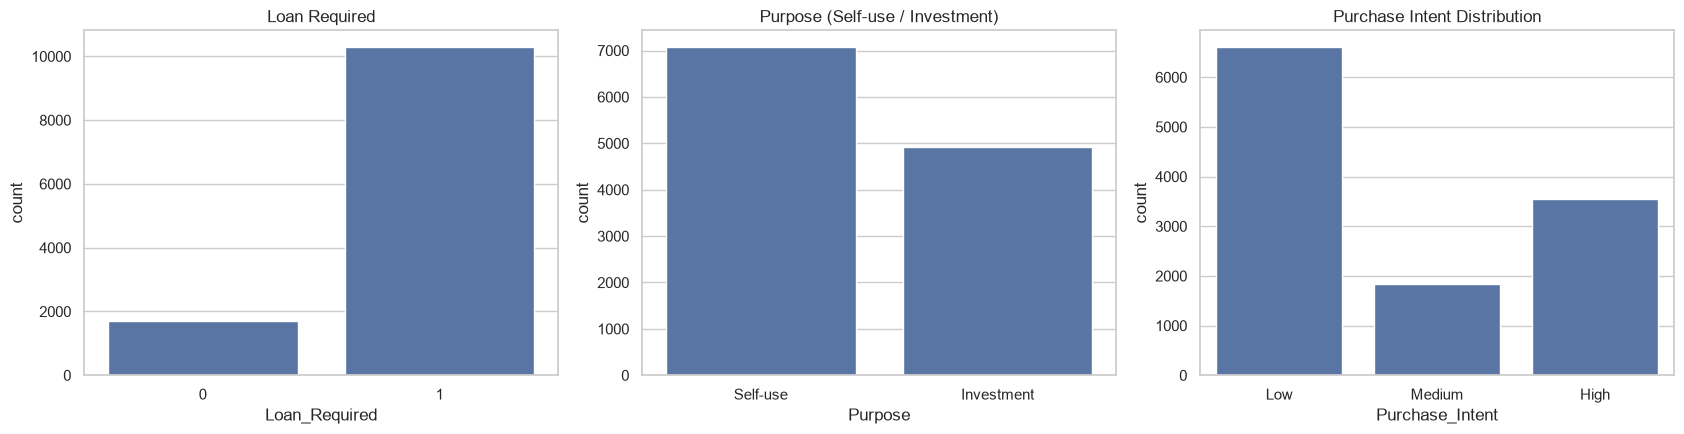

In [9]:
intent_counts = users['Purchase_Intent'].value_counts().reindex(['Low', 'Medium', 'High'])
fig, axes = plt.subplots(1, 3, figsize=(17, 4.5))

sns.countplot(data=users, x='Loan_Required', ax=axes[0])
axes[0].set_title('Loan Required')

sns.countplot(data=users, x='Purpose', ax=axes[1])
axes[1].set_title('Purpose (Self-use / Investment)')

sns.barplot(x=intent_counts.index ,y=intent_counts.values, ax=axes[2])
axes[2].set_title('Purchase Intent Distribution')
plt.ylabel('count')

plt.savefig('../reports/figures/Loan_requirement-Purpose-Purchase_intent.png', dpi=300, bbox_inches='tight')
plt.tight_layout()
plt.show()


## 7. Behavioral funnel vs Purchased (barplot)

For each behavioral step (previous enquiry, site visit, negotiation, booking), we check
what percentage of people who did "Yes" on that step actually purchased. Since
`Purchased` is already 0/1, `groupby().mean()` directly gives us that percentage.


In [10]:
funnel_cols = ['Previous_Enquiry', 'Site_Visit', 'Negotiation_Done', 'Booking_Done']

for col in funnel_cols:
    conversion = users.groupby(col)['Purchased'].mean() * 100
    print(f"--- {col} ---")
    print(conversion.round(1))
    print()


--- Previous_Enquiry ---
Previous_Enquiry
0    37.5
1    46.1
Name: Purchased, dtype: float64

--- Site_Visit ---
Site_Visit
0    16.4
1    54.9
Name: Purchased, dtype: float64

--- Negotiation_Done ---
Negotiation_Done
0    25.9
1    87.6
Name: Purchased, dtype: float64

--- Booking_Done ---
Booking_Done
0     0.0
1    98.1
Name: Purchased, dtype: float64



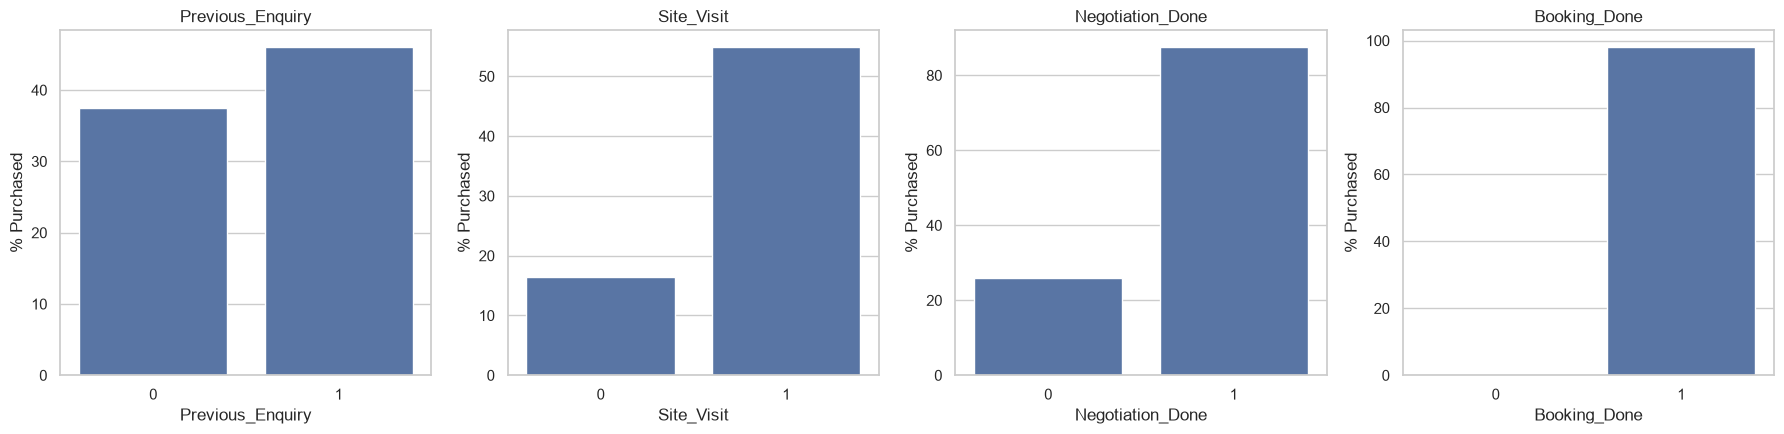

In [11]:
fig, axes = plt.subplots(1, 4, figsize=(18, 4.5))

for ax, col in zip(axes, funnel_cols):
    conversion = users.groupby(col)['Purchased'].mean() * 100
    sns.barplot(x=conversion.index, y=conversion.values, ax=ax)
    ax.set_title(col)
    ax.set_ylabel('% Purchased')

plt.tight_layout()
plt.show()


## 8. Income vs Plot Budget relationship (scatterplot)

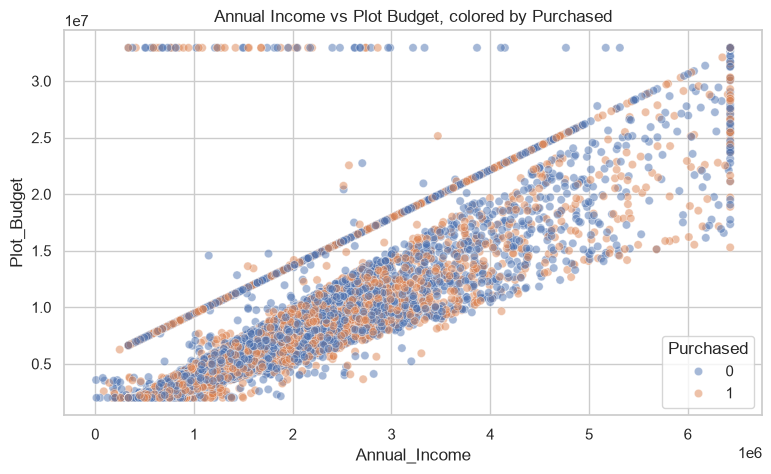

In [12]:
plt.figure()
sns.scatterplot(data=users, x='Annual_Income', y='Plot_Budget', hue='Purchased', alpha=0.5)
plt.title('Annual Income vs Plot Budget, colored by Purchased')
plt.savefig('../reports/figures/income-vs-plot_budget.png', dpi=300, bbox_inches='tight')
plt.show()


## 9. Occupation vs conversion (barplot)

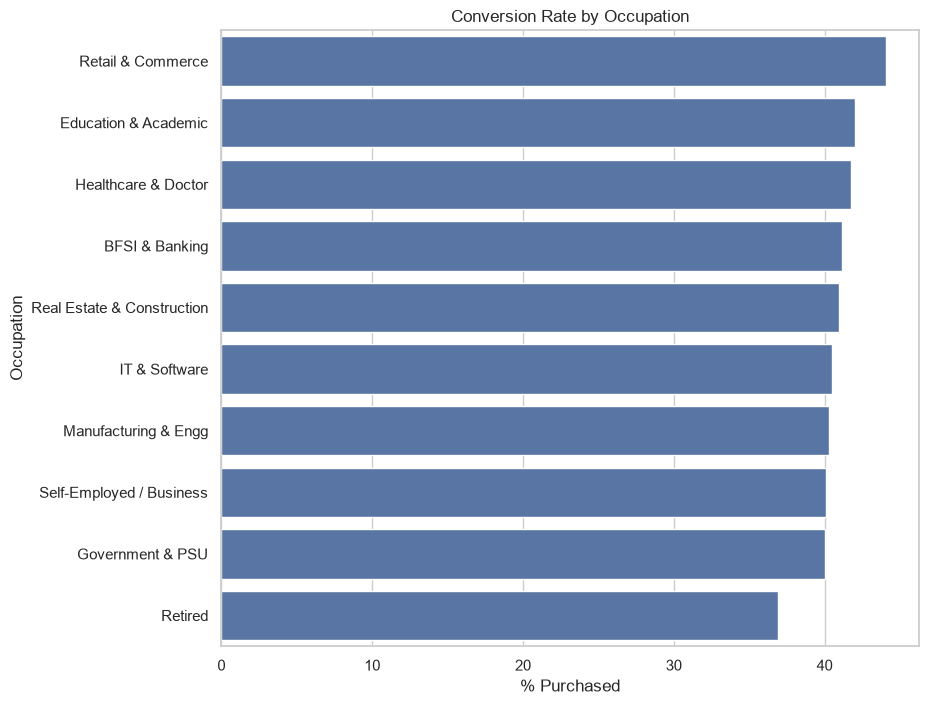

In [13]:
occupation_conversion = users.groupby('Occupation')['Purchased'].mean().sort_values(ascending=False) * 100
"""print(occupation_conversion.round(1))"""

plt.figure(figsize=(9, 8))
sns.barplot(x=occupation_conversion.values, y=occupation_conversion.index)
plt.title('Conversion Rate by Occupation')
plt.xlabel('% Purchased')
plt.savefig('../reports/figures/occupation-vs-conversion.png', dpi=300, bbox_inches='tight')
plt.show()


## 10. Correlation heatmap (numeric features)

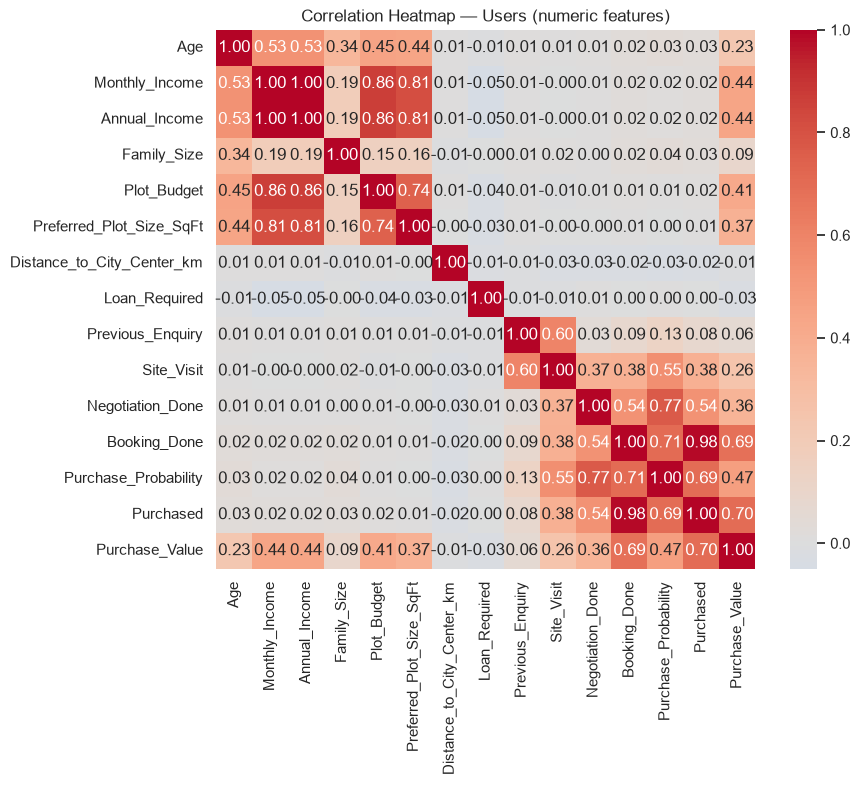

In [14]:
numeric_cols = users.select_dtypes(include='number').columns
corr = users[numeric_cols].corr()

plt.figure(figsize=(9, 7))
sns.heatmap(corr, cmap='coolwarm', center=0, annot=True, fmt='.2f', square=True)
plt.title('Correlation Heatmap — Users (numeric features)')
plt.savefig('../reports/figures/heatmap(users).png', dpi=300, bbox_inches='tight')
plt.show()


---
## Key Takeaways

1. **Class balance (`Purchased`)**
   > **59.25% did not purchase, 40.75% did purchase.** Not extremely imbalanced, but worth
   > keeping in mind for modelling.

2. **Behavioral funnel is the strongest signal**
   > Conversion rate rises sharply at each step: **37.5% → 46.1%** with a previous enquiry,
   > **16.4% → 54.9%** with a site visit, **25.9% → 87.6%** after negotiation, and
   > **0.0% → 98.1%** after a booking is done. `Booking_Done` and `Site_Visit` are by far
   > the strongest predictors of `Purchased` in this dataset.

3. **Financial fields matter far less than behavior**
   > Median `Plot_Budget` is ₹50.15L for non-buyers vs ₹52.2L for buyers, and median
   > `Annual_Income` is ₹12.89L vs ₹13.30L — both differences are small (under 4%).
   > Behavior (funnel steps) separates buyers from non-buyers far more than income or
   > budget does.

4. **Lead source and Occupation both show narrow, weak spreads**
   > Lead source conversion ranges only **39.3%–41.2%** across all 5 sources, and
   > Occupation ranges only **36.9%–44.1%** across all 10 categories. Neither field
   > meaningfully separates buyers from non-buyers on its own — both are much flatter than
   > the funnel columns above.

**Takeaway for modelling:** behavioral columns (`Booking_Done`, `Site_Visit`,
`Negotiation_Done`) are far more predictive of `Purchased` than demographic, financial,
occupation, or lead-source columns — those latter fields add little on their own.